# 03 — Training
Two-phase transfer learning with ResNet-50. OpenCV throughout, CUDA GPU.
6-class: Bacterial_Blight, Blast, Brown_Spot, Tungro, Healthy_Rice_Leaf, Rice_Hispa.

## Imports & config

In [1]:
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from safetensors.torch import save_file, load_file
from pathlib import Path
from collections import Counter
import copy, time, warnings
warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────────
PROCESSED_DIR = Path('../data/processed')
MODEL_PATH    = Path('../models/resnet50_rice.safetensors')
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

CLASSES      = ['Bacterial_Blight', 'Blast', 'Brown_Spot', 'Tungro', 'Healthy_Rice_Leaf', 'Rice_Hispa']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(CLASSES)

IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_WORKERS   = 4
MEAN          = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD           = np.array([0.229, 0.224, 0.225], dtype=np.float32)

PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3
PHASE2_EPOCHS = 20
PHASE2_LR     = 1e-4
ES_PATIENCE   = 5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
if device.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'Classes : {CLASSES}')


Device  : cuda
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
Classes : ['Bacterial_Blight', 'Blast', 'Brown_Spot', 'Tungro', 'Healthy_Rice_Leaf', 'Rice_Hispa']


## Augmentation pipeline

In [2]:
# ── Original augmentations (extended) ─────────────────────────────────────────

def random_horizontal_flip(img, p=0.5):
    return cv2.flip(img, 1) if np.random.rand() < p else img

def random_rotation(img, max_angle=15):
    angle = np.random.uniform(-max_angle, max_angle)
    h, w  = img.shape[:2]
    M     = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

def random_color_jitter(img, brightness=0.2, contrast=0.2, hue_shift=10):
    """Extended: adds hue shift for purple/yellow tone variation in dataset."""
    alpha = 1.0 + np.random.uniform(-contrast, contrast)
    beta  = np.random.uniform(-brightness, brightness) * 255
    img   = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    if np.random.rand() < 0.4:
        hsv        = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.int32)
        hsv[:,:,0] = (hsv[:,:,0] + np.random.randint(-hue_shift, hue_shift)) % 180
        img        = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    return img

def random_crop(img, padding=20):
    """Extended: padding 10 → 20 for partial leaf variation."""
    h, w   = img.shape[:2]
    padded = cv2.copyMakeBorder(img, padding, padding, padding, padding,
                                cv2.BORDER_REFLECT_101)
    top    = np.random.randint(0, 2 * padding)
    left   = np.random.randint(0, 2 * padding)
    return padded[top:top+h, left:left+w]

# ── New field-aware augmentations ─────────────────────────────────────────────

def random_shadow(img, p=0.4):
    """Random polygon shadow simulates uneven field lighting."""
    if np.random.rand() > p:
        return img
    h, w = img.shape[:2]
    pts  = np.array([
        [np.random.randint(0, w), 0],
        [np.random.randint(0, w), 0],
        [np.random.randint(0, w), h],
        [np.random.randint(0, w), h]
    ], np.int32)
    mask   = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    factor = np.random.uniform(0.4, 0.75)
    out    = img.copy().astype(np.float32)
    out[mask == 1] *= factor
    return out.clip(0, 255).astype(np.uint8)

def random_solid_bg_patch(img, p=0.3):
    """Solid-colour patch on one side — simulates blue fabric / wall backgrounds."""
    if np.random.rand() > p:
        return img
    h, w = img.shape[:2]
    out  = img.copy()
    if np.random.rand() < 0.5:
        color = [
            np.random.randint(20,  80),
            np.random.randint(50, 130),
            np.random.randint(120, 200)
        ]
    else:
        c     = np.random.randint(30, 200)
        color = [c, c, c]
    side  = np.random.choice(['left', 'right', 'top', 'bottom'])
    cut_w = np.random.randint(w // 5, w // 2)
    cut_h = np.random.randint(h // 5, h // 2)
    if   side == 'left':   out[:, :cut_w]   = color
    elif side == 'right':  out[:, w-cut_w:] = color
    elif side == 'top':    out[:cut_h, :]   = color
    else:                  out[h-cut_h:, :] = color
    return out

def random_jpeg_compression(img, p=0.4, low=55, high=90):
    """Simulates phone-camera JPEG compression artifacts."""
    if np.random.rand() > p:
        return img
    bgr     = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    q       = np.random.randint(low, high)
    _, enc  = cv2.imencode('.jpg', bgr, [cv2.IMWRITE_JPEG_QUALITY, q])
    bgr_dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return cv2.cvtColor(bgr_dec, cv2.COLOR_BGR2RGB)

# ── Full pipeline ─────────────────────────────────────────────────────────────

def augment(img):
    img = random_horizontal_flip(img)
    img = random_rotation(img)
    img = random_color_jitter(img)
    img = random_crop(img)
    img = random_shadow(img)
    img = random_solid_bg_patch(img)
    img = random_jpeg_compression(img)
    return img

def preprocess(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32) / 255.0
    return (img - MEAN) / STD

def to_tensor(img):
    return torch.from_numpy(np.transpose(img, (2, 0, 1)).copy())

print('Augmentation pipeline ready.')


Augmentation pipeline ready.


## Dataset & DataLoader

In [3]:
class RiceLeafDataset(Dataset):
    def __init__(self, root, train=False):
        self.train   = train
        self.samples = []
        for cls in CLASSES:
            cls_dir = Path(root) / cls
            if not cls_dir.exists():
                print(f'  [WARNING] Missing folder: {cls_dir}')
                continue
            for ext in ('*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png'):
                for p in cls_dir.glob(ext):
                    self.samples.append((p, CLASS_TO_IDX[cls]))
        if not self.samples:
            raise RuntimeError(f'No images found under {root}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(str(path))
        if img is None:
            raise RuntimeError(f'Failed to read: {path}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.train:
            img = augment(img)
        img = preprocess(img)
        return to_tensor(img), label


def make_weighted_sampler(dataset):
    """Equal sampling frequency per class regardless of raw count."""
    counts     = Counter(label for _, label in dataset.samples)
    sample_wts = [1.0 / counts[label] for _, label in dataset.samples]
    return WeightedRandomSampler(sample_wts, num_samples=len(dataset), replacement=True)


train_ds = RiceLeafDataset(PROCESSED_DIR / 'train', train=True)
val_ds   = RiceLeafDataset(PROCESSED_DIR / 'val',   train=False)

# WeightedRandomSampler replaces shuffle=True
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=make_weighted_sampler(train_ds),
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Per-class count table
train_counts = Counter(label for _, label in train_ds.samples)
val_counts   = Counter(label for _, label in val_ds.samples)
print(f'\n{"Class":<22} {"Train":>8} {"Val":>8}')
print('-' * 42)
for i, cls in enumerate(CLASSES):
    print(f'{cls:<22} {train_counts[i]:>8} {val_counts[i]:>8}')
print('-' * 42)
print(f'{"TOTAL":<22} {len(train_ds):>8} {len(val_ds):>8}')
print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')



Class                     Train      Val
------------------------------------------
Bacterial_Blight           2079      471
Blast                      1781      424
Brown_Spot                 2345      503
Tungro                     1515      405
Healthy_Rice_Leaf           914      196
Rice_Hispa                 2137      458
------------------------------------------
TOTAL                     10771     2457

Train batches : 336
Val   batches : 77


## Model — RiceResNet

In [4]:
class RiceResNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        weights       = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        backbone      = models.resnet50(weights=weights)
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.head     = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(2048, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
        for p in self.head.parameters():     p.requires_grad = True

    def unfreeze_top(self):
        for i, child in enumerate(self.backbone.children()):
            for p in child.parameters():
                p.requires_grad = i >= 6   # layer3 + layer4

    def trainable(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = RiceResNet(pretrained=True).to(device)
total = sum(p.numel() for p in model.parameters())
print(f'Model   : ResNet-50  ({total/1e6:.1f}M total params)')
print(f'Classes : {NUM_CLASSES}')
print(f'Device  : {device}')


Model   : ResNet-50  (23.8M total params)
Classes : 6
Device  : cuda


## Training utilities

In [5]:
# Label smoothing prevents overconfident logits on out-of-distribution images
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


class EarlyStopping:
    def __init__(self, patience=5):
        self.patience   = patience
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
            return False
        self.counter += 1
        print(f'  EarlyStopping {self.counter}/{self.patience}')
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f'  Best weights restored (val_loss={self.best_loss:.4f})')


def run_epoch(model, loader, optimizer, train):
    model.train() if train else model.eval()
    total_loss = total_correct = total_n = 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss    += loss.item() * imgs.size(0)
            total_correct += (logits.argmax(1) == labels).sum().item()
            total_n       += imgs.size(0)
    return total_loss / total_n, total_correct / total_n


history = {
    'phase1': {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []},
    'phase2': {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []},
}

print('Training utilities ready.')


Training utilities ready.


## Phase 1 — Head training (backbone frozen)

In [6]:
print('=' * 55)
print('PHASE 1 — Head training (backbone frozen)')
print('=' * 55)
model.freeze_backbone()
print(f'Trainable params: {model.trainable():,}\n')

optimizer1 = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR
)
scheduler1 = ReduceLROnPlateau(optimizer1, mode='min', factor=0.5, patience=3)

for epoch in range(1, PHASE1_EPOCHS + 1):
    t0              = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer1, train=True)
    vl_loss, vl_acc = run_epoch(model, val_loader,   optimizer1, train=False)
    scheduler1.step(vl_loss)
    lr_now          = optimizer1.param_groups[0]['lr']
    print(f'Epoch {epoch:02d}/{PHASE1_EPOCHS} | '
          f'train_loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'val_loss={vl_loss:.4f} acc={vl_acc:.4f} | '
          f'lr={lr_now:.2e} | {time.time()-t0:.1f}s')
    history['phase1']['train_loss'].append(tr_loss)
    history['phase1']['val_loss'].append(vl_loss)
    history['phase1']['train_acc'].append(tr_acc)
    history['phase1']['val_acc'].append(vl_acc)

print('\nPhase 1 complete.')


PHASE 1 — Head training (backbone frozen)
Trainable params: 263,046

Epoch 01/10 | train_loss=0.9791 acc=0.7415 | val_loss=0.6547 acc=0.9101 | lr=1.00e-03 | 83.0s
Epoch 02/10 | train_loss=0.7948 acc=0.8465 | val_loss=0.6273 acc=0.9259 | lr=1.00e-03 | 91.8s
Epoch 03/10 | train_loss=0.7907 acc=0.8444 | val_loss=0.6535 acc=0.9096 | lr=1.00e-03 | 81.6s
Epoch 04/10 | train_loss=0.7684 acc=0.8598 | val_loss=0.6094 acc=0.9430 | lr=1.00e-03 | 95.2s
Epoch 05/10 | train_loss=0.7534 acc=0.8646 | val_loss=0.5921 acc=0.9520 | lr=1.00e-03 | 98.8s
Epoch 06/10 | train_loss=0.7502 acc=0.8679 | val_loss=0.5801 acc=0.9581 | lr=1.00e-03 | 92.2s
Epoch 07/10 | train_loss=0.7378 acc=0.8767 | val_loss=0.5748 acc=0.9569 | lr=1.00e-03 | 88.4s
Epoch 08/10 | train_loss=0.7251 acc=0.8816 | val_loss=0.5652 acc=0.9646 | lr=1.00e-03 | 93.7s
Epoch 09/10 | train_loss=0.7231 acc=0.8842 | val_loss=0.5590 acc=0.9569 | lr=1.00e-03 | 97.1s
Epoch 10/10 | train_loss=0.7213 acc=0.8836 | val_loss=0.5807 acc=0.9520 | lr=1.00e-03

## Phase 2 — Fine-tuning (layer3 + layer4 unfrozen)

In [7]:
print('=' * 55)
print('PHASE 2 — Fine-tuning (layer3 + layer4 unfrozen)')
print('=' * 55)
model.unfreeze_top()
print(f'Trainable params: {model.trainable():,}\n')

optimizer2 = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE2_LR
)
scheduler2 = ReduceLROnPlateau(optimizer2, mode='min', factor=0.5, patience=3)
stopper    = EarlyStopping(patience=ES_PATIENCE)

for epoch in range(1, PHASE2_EPOCHS + 1):
    t0              = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer2, train=True)
    vl_loss, vl_acc = run_epoch(model, val_loader,   optimizer2, train=False)
    scheduler2.step(vl_loss)
    lr_now          = optimizer2.param_groups[0]['lr']
    print(f'Epoch {epoch:02d}/{PHASE2_EPOCHS} | '
          f'train_loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'val_loss={vl_loss:.4f} acc={vl_acc:.4f} | '
          f'lr={lr_now:.2e} | {time.time()-t0:.1f}s')
    history['phase2']['train_loss'].append(tr_loss)
    history['phase2']['val_loss'].append(vl_loss)
    history['phase2']['train_acc'].append(tr_acc)
    history['phase2']['val_acc'].append(vl_acc)
    if stopper.step(vl_loss, model):
        print(f'Early stopping at epoch {epoch}')
        break

stopper.restore(model)
print('\nPhase 2 complete.')


PHASE 2 — Fine-tuning (layer3 + layer4 unfrozen)
Trainable params: 22,326,150

Epoch 01/20 | train_loss=0.5933 acc=0.9531 | val_loss=0.4863 acc=0.9927 | lr=1.00e-04 | 103.6s
Epoch 02/20 | train_loss=0.5077 acc=0.9872 | val_loss=0.4546 acc=0.9972 | lr=1.00e-04 | 111.8s
Epoch 03/20 | train_loss=0.4954 acc=0.9889 | val_loss=0.4417 acc=0.9984 | lr=1.00e-04 | 114.0s
Epoch 04/20 | train_loss=0.4798 acc=0.9928 | val_loss=0.4414 acc=0.9984 | lr=1.00e-04 | 106.9s
Epoch 05/20 | train_loss=0.4766 acc=0.9929 | val_loss=0.4419 acc=0.9972 | lr=1.00e-04 | 114.4s
  EarlyStopping 1/5
Epoch 06/20 | train_loss=0.4699 acc=0.9943 | val_loss=0.4348 acc=0.9996 | lr=1.00e-04 | 106.3s
Epoch 07/20 | train_loss=0.4700 acc=0.9936 | val_loss=0.4316 acc=0.9996 | lr=1.00e-04 | 112.4s
Epoch 08/20 | train_loss=0.4667 acc=0.9939 | val_loss=0.4370 acc=0.9992 | lr=1.00e-04 | 114.2s
  EarlyStopping 1/5
Epoch 09/20 | train_loss=0.4619 acc=0.9956 | val_loss=0.4292 acc=0.9996 | lr=1.00e-04 | 109.1s
Epoch 10/20 | train_loss=0

## Save model

In [8]:
save_file(model.state_dict(), str(MODEL_PATH))
print(f'Model saved  → {MODEL_PATH}')
print(f'Classes      : {CLASSES}')
print(f'Best val_loss: {stopper.best_loss:.4f}')


Model saved  → ../models/resnet50_rice.safetensors
Classes      : ['Bacterial_Blight', 'Blast', 'Brown_Spot', 'Tungro', 'Healthy_Rice_Leaf', 'Rice_Hispa']
Best val_loss: 0.4243


## Training curves

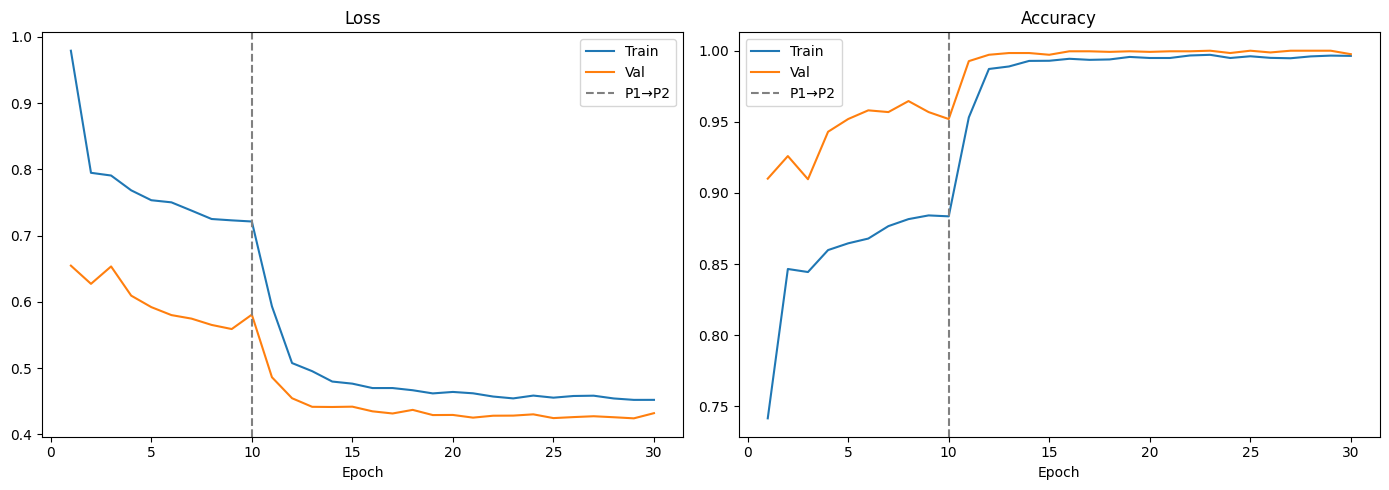

Final val acc  : 0.9976
Final val loss : 0.4321


In [9]:
import matplotlib.pyplot as plt

train_loss = history['phase1']['train_loss'] + history['phase2']['train_loss']
val_loss   = history['phase1']['val_loss']   + history['phase2']['val_loss']
train_acc  = history['phase1']['train_acc']  + history['phase2']['train_acc']
val_acc    = history['phase1']['val_acc']    + history['phase2']['val_acc']
p1_len     = len(history['phase1']['train_loss'])
epochs     = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_loss, label='Train')
axes[0].plot(epochs, val_loss,   label='Val')
axes[0].axvline(p1_len, color='gray', linestyle='--', label='P1→P2')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, train_acc, label='Train')
axes[1].plot(epochs, val_acc,   label='Val')
axes[1].axvline(p1_len, color='gray', linestyle='--', label='P1→P2')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/training_curves.png', dpi=150)
plt.show()
print(f'Final val acc  : {val_acc[-1]:.4f}')
print(f'Final val loss : {val_loss[-1]:.4f}')


## Load model utility

In [10]:
def load_model(path=MODEL_PATH):
    m = RiceResNet(pretrained=False).to(device)
    m.load_state_dict(load_file(str(path)))
    m.eval()
    print(f'Model loaded from {path}')
    return m

# Uncomment to reload without retraining:
# model = load_model()
